In [1]:
import sys
import pandas as pd
import numpy as np
from pathlib import Path

import autoslo.filesystem.path_utils as pu
from autoslo.filesystem.logos_export import logos_df
from autoslo.filesystem.structured_log import StructuredLog
from autoslo.slo.slo_resolver import SloResolver
from autoslo.config.component_configs import SloResolverConfig
from autoslo.filesystem.yaml_helpers import load_yaml
from logos import Logos
from IPython.display import Image

In [2]:
RUN_ID = "1783260865180"
TAUTOLOGICAL = [
    "actual_execution_latency_s", "final_latency_s",
    "slo_s", "slo_overshoot_s", "relative_violation",
]


In [3]:

def compute_concurrent_load(run_id: str, df_logos: pd.DataFrame) -> pd.DataFrame:
    """
    Add two cluster-load features derived from execution-event timestamps.

    n_concurrent_on_cluster_at_start:
        Number of other queries on the same cluster that had already started
        but not yet finished when this query's execution began.

    n_routed_to_cluster_during_exec:
        Number of other queries routed to the same cluster while this query
        was executing (i.e., arrival of new competition mid-run).
    """
    raw = StructuredLog.load(run_id).flat_df(drop_fwd_queries=True)

    routed = (raw[raw["event_type"] == "query_routed"]
              .set_index("query_id")[["cluster_name", "rel_time_s"]]
              .rename(columns={"rel_time_s": "route_time"}))
    starts = (raw[raw["event_type"] == "query_execution_start"]
              .set_index("query_id")["rel_time_s"].rename("start_time"))
    finishes = (raw[raw["event_type"] == "query_execution_finish"]
                .set_index("query_id")["rel_time_s"].rename("finish_time"))

    qinfo = pd.concat([routed, starts, finishes], axis=1).dropna()

    qids    = qinfo.index.to_numpy()
    cluster = qinfo["cluster_name"].to_numpy()
    rt      = qinfo["route_time"].to_numpy()
    st      = qinfo["start_time"].to_numpy()
    ft      = qinfo["finish_time"].to_numpy()
    n       = len(qids)

    # (i, j): is query j on the same cluster as query i?
    same = cluster[:, None] == cluster[None, :]
    not_self = ~np.eye(n, dtype=bool)

    # Feature B: queries j already running when i's execution starts
    #   j.start <= i.start  AND  j.finish > i.start
    concurrent = (
        same & not_self &
        (st[None, :] <= st[:, None]) &
        (ft[None, :] >  st[:, None])
    ).sum(axis=1)

    # Feature C: queries j routed to same cluster during i's execution
    #   i.start <= j.route_time < i.finish
    routed_during = (
        same & not_self &
        (rt[None, :] >= st[:, None]) &
        (rt[None, :] <  ft[:, None])
    ).sum(axis=1)

    load = pd.DataFrame({
        "n_concurrent_on_cluster_at_start": concurrent,
        "n_routed_to_cluster_during_exec":  routed_during,
    }, index=qids)

    df_logos["n_concurrent_on_cluster_at_start"] = (
        df_logos["query_id"].map(load["n_concurrent_on_cluster_at_start"]))
    df_logos["n_routed_to_cluster_during_exec"] = (
        df_logos["query_id"].map(load["n_routed_to_cluster_during_exec"]))

    return df_logos


In [4]:
exec_cfg = load_yaml(pu.get_runs_dir() / RUN_ID / "execution_config.yml")
resolver = SloResolver(SloResolverConfig(
    slo_s=exec_cfg["slo_resolver_config"]["slo_s"],
    slo_dict_filename=exec_cfg["slo_resolver_config"]["slo_dict_filename"],
))
df = logos_df(run_id=RUN_ID, slo_resolver=resolver, include_named_query_features=True)
df = df.drop(columns=[c for c in TAUTOLOGICAL if c in df.columns])

print("Computing concurrent-load features...")
df = compute_concurrent_load(RUN_ID, df)

# Spot-check
load_cols = ["n_concurrent_on_cluster_at_start", "n_routed_to_cluster_during_exec"]
per_query = (df[df["event_type"] == "query_routed"]
             .set_index("query_id")[load_cols])
print(f"\n  n_concurrent_on_cluster_at_start:")
print(f"    {per_query['n_concurrent_on_cluster_at_start'].value_counts().sort_index().to_dict()}")
print(f"  n_routed_to_cluster_during_exec:")
print(f"    {per_query['n_routed_to_cluster_during_exec'].value_counts().sort_index().to_dict()}")


Loading model checkpoint from /home/markakis/chunkbench/data/iconq_models/model_v8/model_1782160265.pth
Computing concurrent-load features...

  n_concurrent_on_cluster_at_start:
    {0.0: 423, 1.0: 300, 2.0: 232, 3.0: 143, 4.0: 85, 5.0: 55, 6.0: 33, 7.0: 22, 8.0: 18, 9.0: 19, 10.0: 15, 11.0: 9, 12.0: 7, 13.0: 7, 14.0: 5, 15.0: 5, 16.0: 5, 17.0: 3, 18.0: 2, 19.0: 1, 20.0: 1, 21.0: 1, 22.0: 1}
  n_routed_to_cluster_during_exec:
    {0.0: 444, 1.0: 295, 2.0: 214, 3.0: 149, 4.0: 78, 5.0: 57, 6.0: 35, 7.0: 20, 8.0: 16, 9.0: 17, 10.0: 15, 11.0: 11, 12.0: 8, 13.0: 8, 14.0: 6, 15.0: 5, 16.0: 3, 17.0: 2, 18.0: 1, 19.0: 2, 20.0: 2, 21.0: 2, 22.0: 1, 23.0: 1}


In [5]:
plan_cols = [c for c in df.columns if "#" in c]
per_unit  = ["slo_violated", "selected_rpu", "prediction_error"] + plan_cols + load_cols

workdir = '.'

lg = Logos.from_parsed_table(
    data=df,
    workdir=workdir,
    source_id="structured_log_p29",
    template_col="event_type",
    passthrough_cols=["query_id", "query_text_id"],
    per_unit_cols=per_unit,
)
lg.set_causal_unit("query_id")
lg.prepare(default_imp="zero_imp", force=True)

plog = lg.prepared_log
pv   = lg.prepared_variables

print(f"\nPrepared variables : {lg.num_prepared_variables}")
print(f"Causal units       : {len(plog)}\n")


def col(tag: str) -> str:
    rows = pv[pv["Tag"] == tag]
    if rows.empty:
        raise KeyError(f"Tag not found: {tag!r}")
    return rows["Name"].values[0]


pred_tag = "prediction_error mean"
slo_tag  = "slo_violated mean"

pred_col = col(pred_tag)
conc_col = col("n_concurrent_on_cluster_at_start mean")
rdur_col = col("n_routed_to_cluster_during_exec mean")

print("─" * 65)
print("Baseline statistics")
print("─" * 65)
print(f"  prediction_error  mean={plog[pred_col].mean():+.3f}  "
      f"std={plog[pred_col].std():.3f}  "
      f"p90={np.percentile(plog[pred_col], 90):+.3f}")
print(f"  n_concurrent_at_start  mean={plog[conc_col].mean():.2f}  "
      f"max={plog[conc_col].max():.0f}")
print(f"  n_routed_during_exec   mean={plog[rdur_col].mean():.2f}  "
      f"max={plog[rdur_col].max():.0f}")

print("\n  Pearson r with prediction_error:")
print(f"    n_concurrent_at_start : "
      f"{plog[[pred_col, conc_col]].corr().iloc[0,1]:+.4f}")
print(f"    n_routed_during_exec  : "
      f"{plog[[pred_col, rdur_col]].corr().iloc[0,1]:+.4f}")

Imputing missing values...:   0%|          | 0/345 [00:00<?, ?it/s]

One-hot encoding categorical variables...:   0%|          | 0/29 [00:00<?, ?it/s]


Prepared variables : 339
Causal units       : 1392

─────────────────────────────────────────────────────────────────
Baseline statistics
─────────────────────────────────────────────────────────────────
  prediction_error  mean=+20.165  std=95.990  p90=+36.428
  n_concurrent_at_start  mean=2.37  max=22
  n_routed_during_exec   mean=2.37  max=23

  Pearson r with prediction_error:
    n_concurrent_at_start : +0.2246
    n_routed_during_exec  : +0.2189


In [7]:
lg.rank_candidate_causes('slo_violated mean')

,Candidate,Candidate Tag,Target Tag,Slope,P-value,Candidate->Target Edge Status,Target->Candidate Edge Status
0,17060c6a_0+mean,prediction_error mean,slo_violated mean,0.001491,2.065270e-82,Undecided,Undecided
1,a7f9977c_0+mean,n_concurrent_on_cluster_at_start mean,slo_violated mean,0.036396,5.900152e-51,Undecided,Undecided


In [8]:
lg.accept('prediction_error mean', 'slo_violated mean')
lg.rank_candidate_causes('prediction_error mean')

,Candidate,Candidate Tag,Target Tag,Slope,P-value,Candidate->Target Edge Status,Target->Candidate Edge Status
0,ebdcf81f_8+last=autoslo-16-1783260865180-9,routing_score selected_cluster_name last autos...,prediction_error mean,1.998180e+02,6.101948e-20,Undecided,Undecided
1,a7f9977c_0+mean,n_concurrent_on_cluster_at_start mean,prediction_error mean,6.850359e+00,2.205113e-17,Undecided,Undecided
2,30e0d9b5_0+mean,n_routed_to_cluster_during_exec mean,prediction_error mean,6.455428e+00,1.450467e-16,Undecided,Undecided
3,8bbdd445_0+mean,query_execution_finish wall_clock_s mean,prediction_error mean,1.130801e-08,9.251658e-15,Undecided,Undecided
4,c3079922_0+mean,query_execution_start wall_clock_s mean,prediction_error mean,1.130801e-08,9.251806e-15,Undecided,Undecided
5,133bdb9d_0+mean,query_routed wall_clock_s mean,prediction_error mean,1.130801e-08,9.251806e-15,Undecided,Undecided
6,ef3b209b_0+mean,routing wall_clock_s mean,prediction_error mean,1.130801e-08,9.251806e-15,Undecided,Undecided
7,0d4144ff_0+mean,arrival wall_clock_s mean,prediction_error mean,1.130801e-08,9.251806e-15,Undecided,Undecided
8,84dae2fe_0+mean,selected_rpu mean,prediction_error mean,2.082694e+00,3.703466e-07,Undecided,Undecided
9,3609b411_1+mean,latency_update rel_time_s mean,prediction_error mean,2.653923e-03,2.328970e-06,Undecided,Undecided


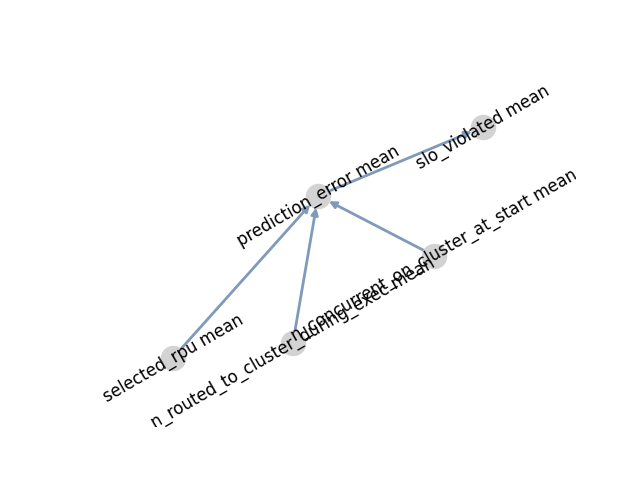

In [9]:
lg.accept('n_concurrent_on_cluster_at_start mean', pred_tag)
lg.accept('n_routed_to_cluster_during_exec mean', pred_tag)
lg.accept('selected_rpu mean', pred_tag)
lg.save_graph('/tmp/g.png') or Image('/tmp/g.png')

In [10]:
print(lg.get_adjusted_ate('selected_rpu mean', pred_tag))
print(lg.get_adjusted_ate('n_concurrent_on_cluster_at_start mean', pred_tag))
print(lg.get_adjusted_ate('n_routed_to_cluster_during_exec mean', pred_tag))

0.981761940078326
4.969221813348704
4.652186357820986


In [12]:
lg.get_causal_graph_refinement_suggestion('n_concurrent_on_cluster_at_start mean', pred_tag)

('selected_rpu mean', 'n_concurrent_on_cluster_at_start mean')

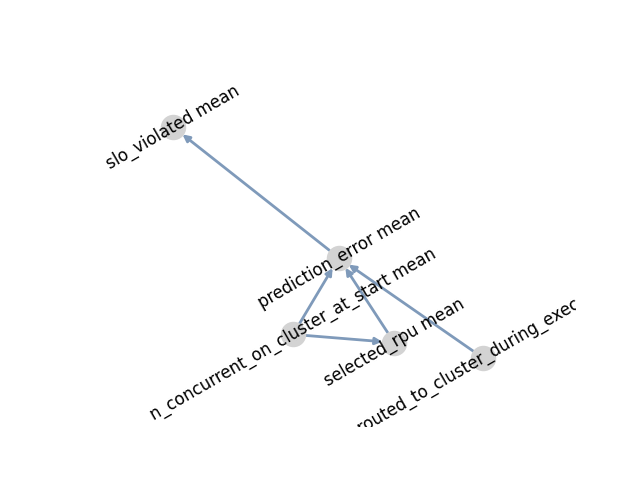

In [13]:
lg.accept('n_concurrent_on_cluster_at_start mean', 'selected_rpu mean')
lg.save_graph('/tmp/g.png') or Image('/tmp/g.png')

In [14]:
print(lg.get_adjusted_ate('selected_rpu mean', pred_tag))
print(lg.get_adjusted_ate('n_concurrent_on_cluster_at_start mean', pred_tag))
print(lg.get_adjusted_ate('n_routed_to_cluster_during_exec mean', pred_tag))

1.1257182287255363
6.267998990939243
4.652186357820986


In [15]:
all_cands = lg.rank_candidate_causes('prediction_error mean', prune_candidates=True)['Candidate Tag'].to_list()
plan_cands = [c for c in all_cands if "#" in c]
plan_cands

['web_site#cardinality mean',
 'inventory#cardinality mean',
 'XN Hash Join DS_DIST_INNER#count mean',
 'store_sales#cardinality mean',
 'store_returns#cardinality mean',
 'query_text_id last ext_tpcds1000#003#001',
 'XN Hash#cardinality mean',
 'promotion#cardinality mean',
 'catalog_page#cardinality mean']

In [16]:
for c in plan_cands:
    lg.accept(c, 'prediction_error mean')
    lg.accept(c, 'selected_rpu mean')

In [17]:
print(lg.get_adjusted_ate('selected_rpu mean', pred_tag))
print(lg.get_adjusted_ate('n_concurrent_on_cluster_at_start mean', pred_tag))
print(lg.get_adjusted_ate('n_routed_to_cluster_during_exec mean', pred_tag))

1.084644950906523
6.314656729508811
4.452239985297933
